In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureRavdess.csv')

In [3]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [4]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,0.1,0.2,speaker
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037,1,1,1
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626,1,1,1
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532,1,1,1
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753,1,1,1
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015,0,8,24
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375,0,8,24
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219,0,8,24
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220,0,8,24


In [5]:
df = data

In [6]:
df.shape

(1440, 196)

In [7]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,0.1,0.2,speaker
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037,1,1,1
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626,1,1,1
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532,1,1,1
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753,1,1,1
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015,0,8,24
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375,0,8,24
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219,0,8,24
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220,0,8,24


In [8]:
data.iloc[:,-3] == 1 

0        True
1        True
2        True
3        True
4        True
        ...  
1435    False
1436    False
1437    False
1438    False
1439    False
Name: 0.1, Length: 1440, dtype: bool

In [9]:
X = df.iloc[:, :40].copy()
y = df.iloc[:,-2].copy()

In [10]:
X

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,-1.627463,-3.258081,-2.374571,-2.986023,-2.994174,-2.629926,-0.439017,-2.969199,-3.328445,-2.600001
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,-1.280527,-3.647095,-2.002587,-3.505500,-3.071092,-1.579813,-0.899086,-4.219514,-3.144018,-3.335574
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,-1.751716,-3.179489,-2.378813,-2.930585,-2.756831,-3.016411,-0.853317,-3.885773,-3.591683,-3.337018
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,-2.445284,-3.353117,-3.061760,-3.655032,-2.925077,-2.213563,-0.704934,-3.643078,-3.353248,-4.489711
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,-1.829067,-2.080756,-1.566609,-3.579078,-1.320512,-1.281256,-1.311444,-2.813618,-3.789509,-3.970030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,-1.084799,0.428676,1.825948,0.438060,-1.230022,-2.260234,-1.394105,-0.999253,-0.450219,-0.286903
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,-1.447214,-0.562955,-0.397673,-0.216449,-0.432767,0.838848,-1.780653,-1.716104,-0.813257,-0.861170
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,1.011409,0.889101,-0.775486,-0.526071,-0.588120,0.558064,-0.759211,-0.930253,-0.515986,-0.572553
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,-0.865850,0.745103,-1.739304,-0.638832,-0.769184,0.613665,0.836838,0.509947,-1.108509,1.077186


In [11]:
y

0       1
1       1
2       1
3       1
4       2
       ..
1435    8
1436    8
1437    8
1438    8
1439    8
Name: 0.2, Length: 1440, dtype: int64

In [12]:
X.shape, y.shape

((1440, 40), (1440,))

In [13]:
from sklearn.preprocessing import LabelEncoder

lb = LabelEncoder()
y_encoded = lb.fit_transform(y)

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [15]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


svm_clf = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)
y_pred_svm = svm_clf.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.3819444444444444
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        19
           1       0.35      0.95      0.51        38
           2       0.34      0.29      0.31        38
           3       0.56      0.13      0.21        38
           4       0.68      0.54      0.60        39
           5       0.44      0.18      0.25        39
           6       0.25      0.34      0.29        38
           7       0.38      0.44      0.40        39

    accuracy                           0.38       288
   macro avg       0.37      0.36      0.32       288
weighted avg       0.40      0.38      0.35       288

SVM Confusion Matrix:
 [[ 0 15  0  0  0  0  4  0]
 [ 0 36  0  0  0  0  2  0]
 [ 0  9 11  1  3  7  3  4]
 [ 0 19  3  5  1  0  7  3]
 [ 0  2  5  0 21  0  5  6]
 [ 0  6  4  2  6  7  8  6]
 [ 0 10  5  0  0  1 13  9]
 [ 0  7  4  1  0  1  9 17]]


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

In [16]:
import seaborn as sns

def plot_cm(y_true, y_pred, classes, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # row-wise percentage
    plt.figure(figsize=(7,6))
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=classes, yticklabels=classes)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title(title)
    plt.show()

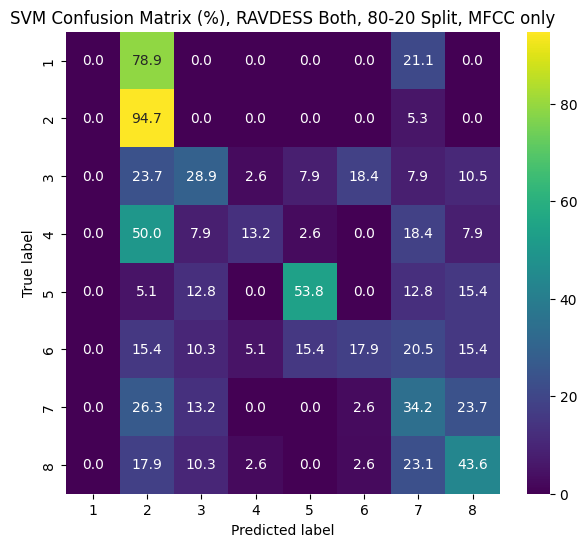

In [17]:
class_names = lb.classes_
plot_cm(y_test, y_pred_svm, class_names, title='SVM Confusion Matrix (%), RAVDESS Both, 80-20 Split, MFCC only')

In [18]:
rf_clf = RandomForestClassifier(
    n_estimators=100, max_depth=None, random_state=42
)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF Classification Report:\n", classification_report(y_test, y_pred_rf))
print("RF Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

RF Accuracy: 0.59375
RF Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.37      0.44        19
           1       0.47      0.87      0.61        38
           2       0.50      0.50      0.50        38
           3       0.53      0.42      0.47        38
           4       0.84      0.69      0.76        39
           5       0.69      0.69      0.69        39
           6       0.68      0.61      0.64        38
           7       0.59      0.49      0.54        39

    accuracy                           0.59       288
   macro avg       0.61      0.58      0.58       288
weighted avg       0.61      0.59      0.59       288

RF Confusion Matrix:
 [[ 7  9  1  1  0  0  1  0]
 [ 3 33  0  2  0  0  0  0]
 [ 0  6 19  2  1  5  1  4]
 [ 2 11  3 16  0  5  0  1]
 [ 0  2  3  1 27  0  3  3]
 [ 0  2  5  2  1 27  2  0]
 [ 0  4  1  3  2  0 23  5]
 [ 1  3  6  3  1  2  4 19]]


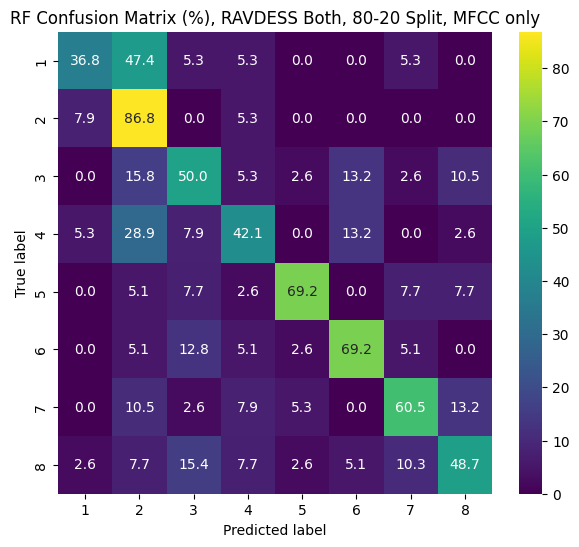

In [19]:
plot_cm(y_test, y_pred_rf, class_names, title='RF Confusion Matrix (%), RAVDESS Both, 80-20 Split, MFCC only')